# explorative data analysis

In [118]:
# import modules 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
pd.set_option('display.float_format', '{:.2f}'.format)


In [119]:
# load dataset

df = pd.read_csv(
    "C:/Users/heike/Desktop/Stackfuel/Portfolio/llm-sustainability-analysis/01_data/03_features/conversation_features.csv"
)

print(df.shape)
# df.head()


(52579, 27)


In [120]:
df.describe()

,first_prompt_tokens,first_response_tokens,total_turns,interaction_rounds,total_user_tokens,total_assistant_tokens,total_tokens,log_total_tokens,follow_up_prompts,needs_follow_up,...,has_audience_or_level_instruction,has_format_instruction,question_count,orthographic_error_rate,topic_id,has_question,multi_question,target_cost,target_depth,target_success
count,52579.00,52579.00,52579.00,52579.00,52579.00,52579.00,52579.00,52579.00,52579.00,52579.00,...,52579.00,52579.00,52579.00,52579.00,52579.00,52579.00,52579.00,52579.00,52579.00,52579.00
mean,153.42,484.43,15.32,7.66,598.62,3823.94,4422.56,7.45,6.68,0.72,...,0.01,0.24,0.57,0.05,2.27,0.35,0.05,7.45,2.18,0.28
std,625.09,631.50,31.02,15.51,2480.75,9496.78,10535.76,1.33,15.72,0.45,...,0.09,0.42,2.76,0.08,2.40,0.48,0.22,1.33,0.99,0.45
min,2.00,1.00,2.00,1.00,5.00,1.00,22.00,3.14,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.14,1.10,0.00
25%,14.00,155.00,2.00,1.00,41.00,513.00,654.50,6.49,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6.49,1.10,0.00
50%,30.00,325.00,6.00,3.00,122.00,1344.00,1641.00,7.40,2.00,1.00,...,0.00,0.00,0.00,0.02,2.00,0.00,0.00,7.40,1.95,0.00
75%,94.00,570.00,16.00,8.00,399.00,3573.00,4246.00,8.35,7.00,1.00,...,0.00,0.00,1.00,0.08,4.00,1.00,0.00,8.35,2.83,1.00
max,55589.00,51880.00,844.00,422.00,168177.00,358980.00,360095.00,12.79,547.00,1.00,...,1.00,1.00,218.00,1.00,7.00,1.00,1.00,12.79,6.74,1.00


## targets

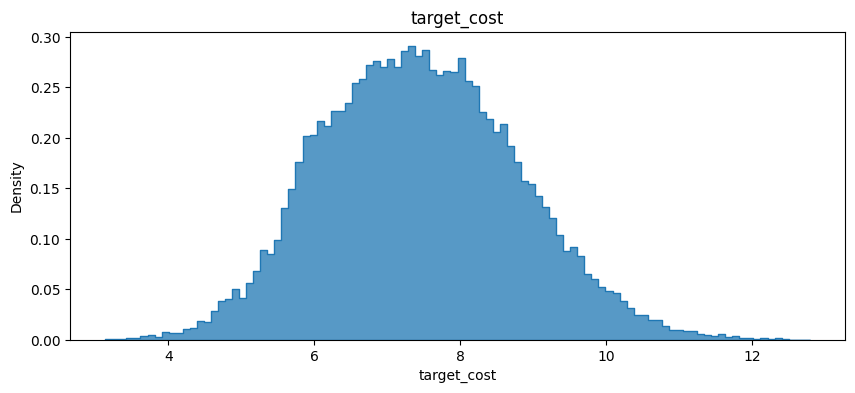

In [121]:
plt.figure(figsize=(10, 4))

sns.histplot(
    data=df,
    x="target_cost",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("target_cost")
plt.xlabel("target_cost")
plt.ylabel("Density")

plt.show()

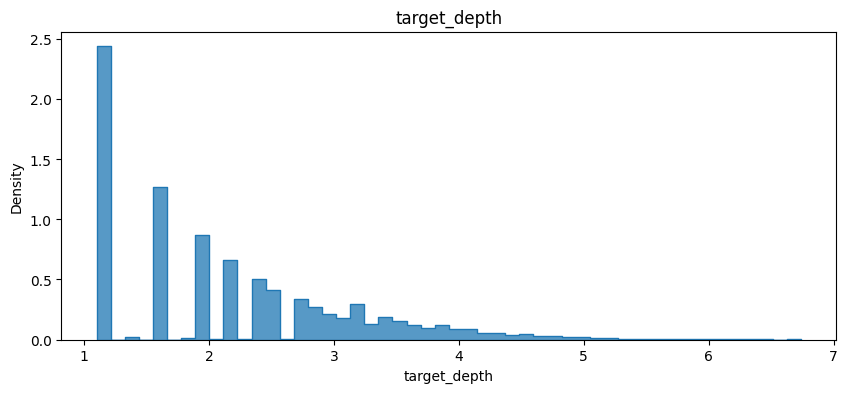

In [122]:
plt.figure(figsize=(10, 4))

sns.histplot(
    data=df,
    x="target_depth",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("target_depth")
plt.xlabel("target_depth")
plt.ylabel("Density")

plt.show()

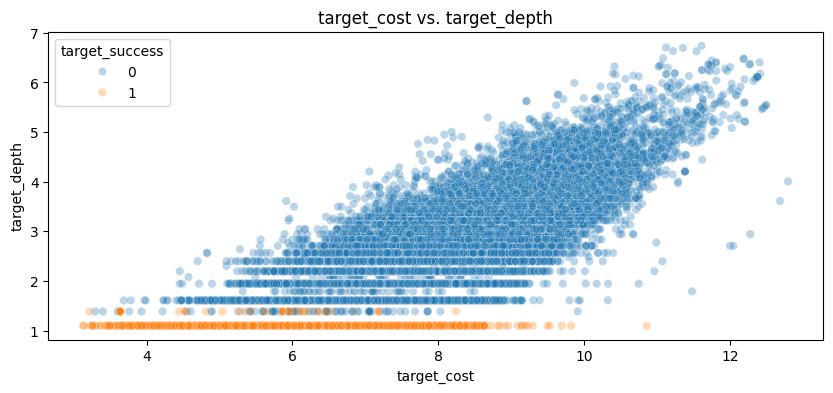

292
12430


In [123]:
plt.figure(figsize=(10, 4))

sns.scatterplot(
    data=df,
    x="target_cost",
    y="target_depth",
    hue="target_success",
    alpha=0.3
)

plt.title("target_cost vs. target_depth")
plt.show()    

print(df["target_depth"].nunique())
print(df["target_cost"].nunique())

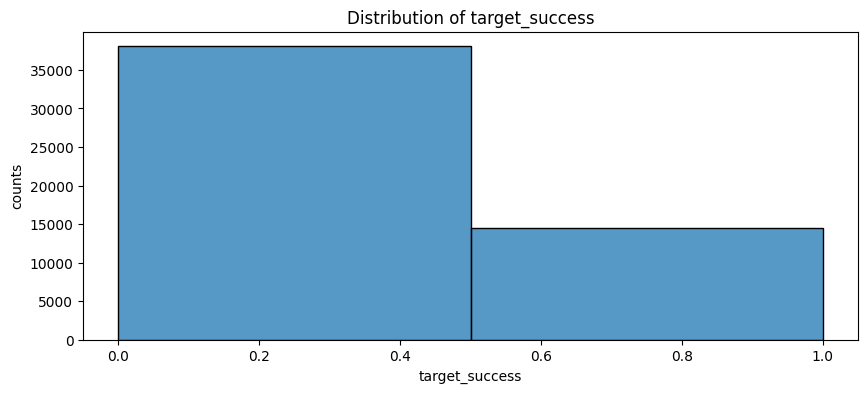

In [124]:
# target_cost

plt.figure(figsize=(10, 4))

sns.histplot(
    data=df,
    x="target_success",
    bins=2
)

plt.title("Distribution of target_success")
plt.ylabel("counts")

plt.show()

## features

#### prompt length

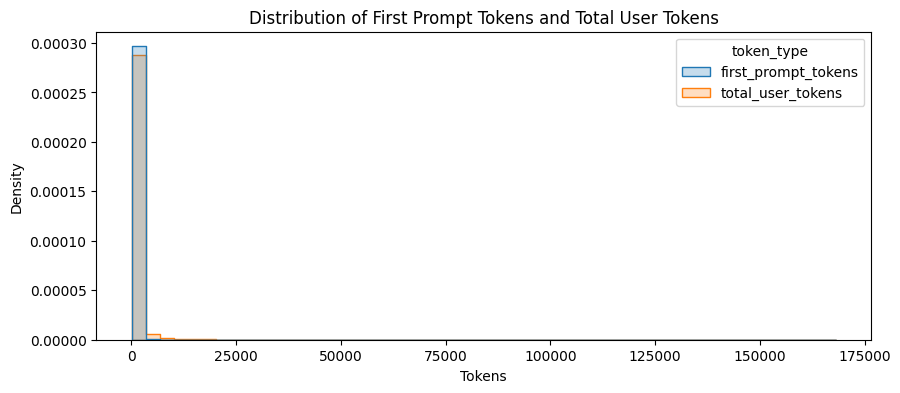

In [125]:
plot_data = df[["first_prompt_tokens", "total_user_tokens"]].melt(
    var_name="token_type",
    value_name="tokens"
)

plt.figure(figsize=(10, 4))

sns.histplot(
    data=plot_data,
    x="tokens",
    hue="token_type",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Distribution of First Prompt Tokens and Total User Tokens")
plt.xlabel("Tokens")
plt.ylabel("Density")

plt.show()

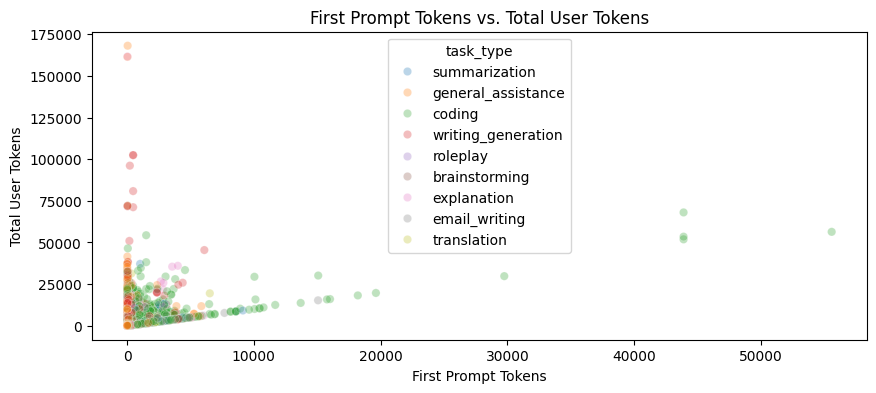

In [126]:
# graph first prompt tokens vs. total user tokens

plt.figure(figsize=(10, 4))

sns.scatterplot(
    data=df,
    x="first_prompt_tokens",
    y="total_user_tokens",
    hue="task_type",
    alpha=0.3
)

plt.title("First Prompt Tokens vs. Total User Tokens")
plt.xlabel("First Prompt Tokens")
plt.ylabel("Total User Tokens")

plt.show()

In [127]:
df.sort_values("first_prompt_tokens", ascending=False)[
    ["conversation_id", "first_prompt_tokens", "first_prompt", "task_type"]
].head(20)


,conversation_id,first_prompt_tokens,first_prompt,task_type
30130,kuqaRcr,55589,"The braiding/weaving in custom that @Caffeine Delusions came up with, came from Novayan spacers ...",coding
26107,cPKBVkS,43904,The following is a transcript of a conversation between me and ChatGPT. Use it for context in th...,coding
22410,Brm0BNU,43904,The following is a transcript of a conversation between me and ChatGPT. Use it for context in th...,coding
35334,3Hnh7LS,43904,The following is a transcript of a conversation between me and ChatGPT. Use it for context in th...,coding
39836,ccnP4d1,29757,Below are the Management’s Discussion and Analysis of Financial Condition and Results of Operati...,coding
12813,6K38nGW,19631,Playright Children’s Play Association\n\n1\tAbout the job: Assistant Manager (Hospital Play Proj...,coding
47878,W0mpVwq,18203,"give me a point form summary of this transcript. Each point is a sentence. ""as more information ...",coding
16294,8njjVZQ,16009,"Title: ""(363) The Wisdom of Iris: Collaborative Sensemaking with AI w/ John Ash - YouTube""\nVide...",coding
38327,B80Ge96,15770,Can you please give me a paragaph summary of this paper? Prefix-Tuning: Optimizing Continuous Pr...,coding
46279,gLlrJQj,15078,"What is the problem statement for ""The Potential of AI in Unified Commerce: How Dynamic Pricing ...",coding


In [128]:
df["first_prompt_tokens"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count   52579.00
mean      153.42
std       625.09
min         2.00
50%        30.00
75%        94.00
90%       334.00
95%       690.00
99%      2097.00
max     55589.00
Name: first_prompt_tokens, dtype: float64

Token distributions were highly right-skewed. Therefore, plots were shown with the upper 1% trimmed for readability, while outliers were inspected separately.

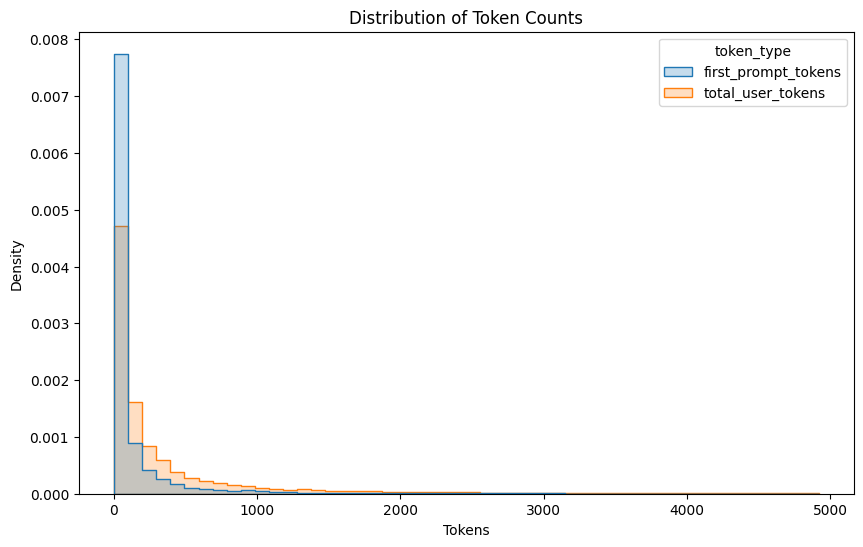

In [129]:
upper_limit = plot_data["tokens"].quantile(0.99)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_data[plot_data["tokens"] <= upper_limit],
    x="tokens",
    hue="token_type",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Distribution of Token Counts")
plt.xlabel("Tokens")
plt.ylabel("Density")

plt.show()

In [130]:
df["long_context_prompt"] = df["first_prompt_tokens"] > df["first_prompt_tokens"].quantile(0.95)
df["long_context_prompt"] = (df["first_prompt_tokens"] > 2000).astype(int)
df["long_context_prompt"].value_counts()

long_context_prompt
0    52007
1      572
Name: count, dtype: int64

In [131]:
df.groupby("long_context_prompt")[[
    "first_prompt_tokens",
    "total_user_tokens",
    "total_tokens",
    "follow_up_prompts"
]].median()

,first_prompt_tokens,total_user_tokens,total_tokens,follow_up_prompts
long_context_prompt,,,,
0,29.00,119.00,1611.00,2.00
1,2744.00,3163.50,5090.00,2.00


In [132]:
df.sort_values("total_tokens", ascending=False)[
    ["conversation_id", "total_tokens", "interaction_rounds", "follow_up_prompts", "first_prompt", "task_type"]
].head(5)

,conversation_id,total_tokens,interaction_rounds,follow_up_prompts,first_prompt,task_type
25794,916vNWn,360095,27.00,26,give me code for pong in pygame with keyboard inputs,general_assistance
43732,YPuViSO,322564,18.00,17,Give me python code for creating a heatmap of the joint frequency of red vs blue (in the sense o...,coding
52554,owoSt1j,266067,127.00,126,"As a .NET C# architect with expertise in all types of authorization, including RBAC, ABAC, PBAC,...",general_assistance
49101,eMCJFR7,266067,127.00,126,"As a .NET C# architect with expertise in all types of authorization, including RBAC, ABAC, PBAC,...",general_assistance
16134,rmRwxPP,259499,122.00,121,"As a .NET C# architect with expertise in all types of authorization, including RBAC, ABAC, PBAC,...",general_assistance


#### turns / follow-ups


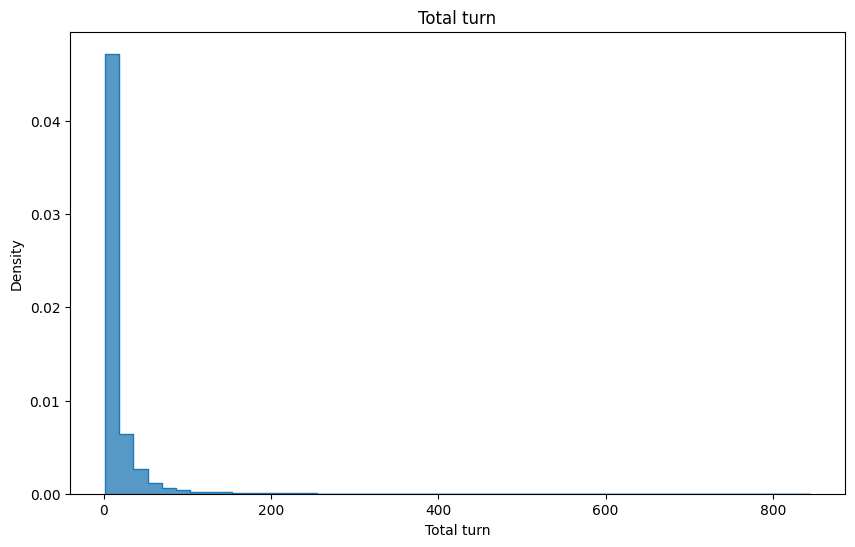

In [133]:
plot_data = df[["total_turns"]]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_data,
    x="total_turns",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Total turn")
plt.xlabel("Total turn")
plt.ylabel("Density")

plt.show()

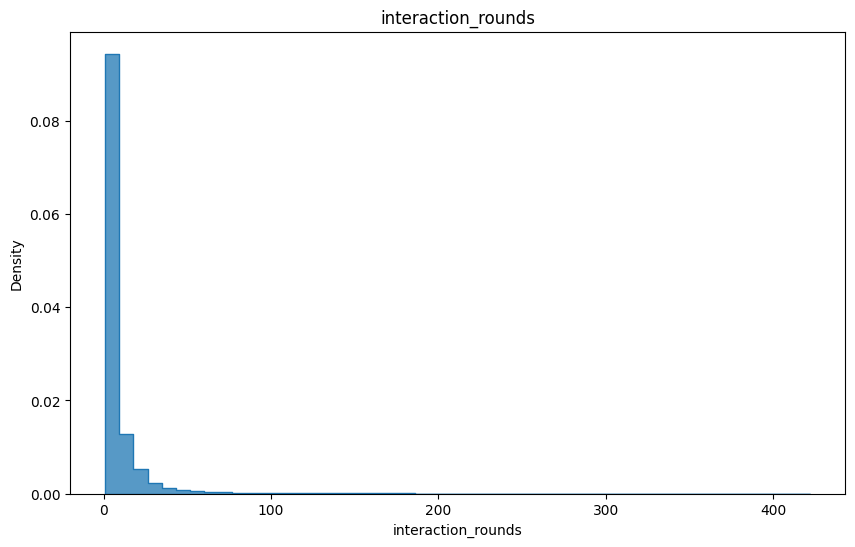

In [134]:
plot_data = df[["interaction_rounds"]]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_data,
    x="interaction_rounds",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("interaction_rounds")
plt.xlabel("interaction_rounds")
plt.ylabel("Density")

plt.show()

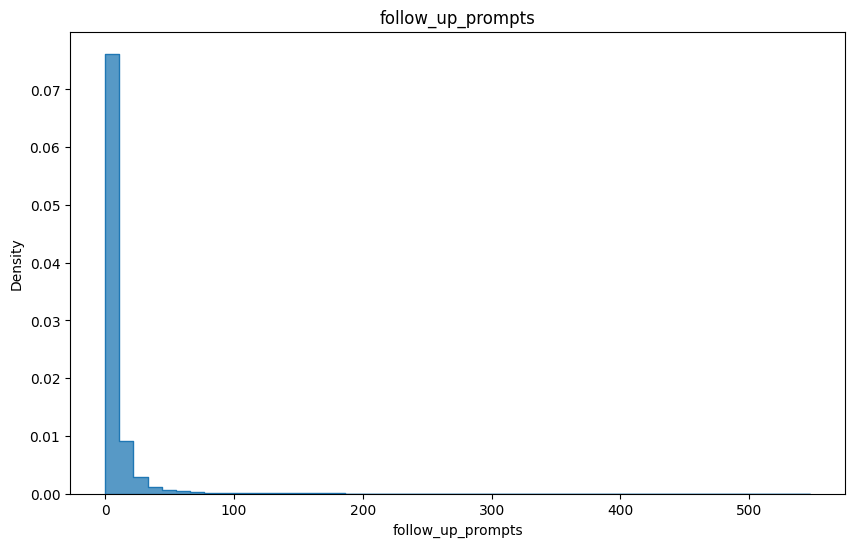

In [135]:
plot_data = df[["follow_up_prompts"]]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_data,
    x="follow_up_prompts",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("follow_up_prompts")
plt.xlabel("follow_up_prompts")
plt.ylabel("Density")

plt.show()

In [136]:
df[["follow_up_prompts", "interaction_rounds", "total_turns"]].corr()

,follow_up_prompts,interaction_rounds,total_turns
follow_up_prompts,1.00,1.00,1.00
interaction_rounds,1.00,1.00,1.00
total_turns,1.00,1.00,1.00


In [137]:
df["interaction_rounds"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count   52579.00
mean        7.66
std        15.51
min         1.00
50%         3.00
75%         8.00
90%        17.00
95%        27.00
99%        67.00
max       422.00
Name: interaction_rounds, dtype: float64

In [138]:
pd.set_option("display.max_colwidth", 100)

df.sort_values("interaction_rounds", ascending=False)[
    [
        "conversation_id",
        "interaction_rounds",
        "follow_up_prompts",
        "first_prompt",
        "task_type",
    ]
].head(20)

,conversation_id,interaction_rounds,follow_up_prompts,first_prompt,task_type
23667,ws31yJX,422.00,421,Do you remember what I told you about using peer review of social media posts instead of fact-ch...,general_assistance
51679,YlgTw57,407.50,547,"write a detailed story about two siblings, who are very close and love each other passionately i...",writing_generation
39618,hgq98Ee,403.50,403,"In summary, Elena gave David a new iPhone 14 Pro Max on Christmas day but he destroyed it right ...",summarization
25162,0WD4DuK,379.00,378,Can you rewrite this sentence in a definitive way that a 4th grader can understand:\n\nTime’s li...,writing_generation
33189,VKvyZfa,377.50,377,Is it true most people consider themselves smarter than others?,general_assistance
24887,ToxFax1,327.00,326,"hi! i will be writing some blogs about Family Vacation Rentals, a brand that provides a listing ...",general_assistance
24329,PfiDxfU,324.00,323,"I would like a book on ""all about taking care of your body and keeping your body healthy from ba...",writing_generation
14978,3D3oQC0,324.00,323,"I would like a book on ""all about taking care of your body and keeping your body healthy from ba...",writing_generation
8918,rZlqeCo,313.50,313,I'll be giving you some stuff to read and then asking questions based on the story concept descr...,writing_generation
34577,AKhF7L9,302.00,301,I want to make machine learning-based model that could help them plan and respond more effective...,general_assistance


#### task types

In [139]:
task_token_summary = df.groupby("task_type").agg(
    conversations=("conversation_id", "count"),
    median_total_tokens=("total_tokens", "median"),
    mean_total_tokens=("total_tokens", "mean"),
    total_token_sum=("total_tokens", "sum"),
    median_interactions=("interaction_rounds", "median"),
    mean_needs_follow_up=("needs_follow_up", "mean"),
    mean_role_instruction=("has_role_instruction", "mean"),
    mean_audience_instruction=("has_audience_or_level_instruction", "mean"),
    mean_format_instruction=("has_format_instruction", "mean")
).sort_values("median_total_tokens", ascending=False)


task_token_summary

,conversations,median_total_tokens,mean_total_tokens,total_token_sum,median_interactions,mean_needs_follow_up,mean_role_instruction,mean_audience_instruction,mean_format_instruction
task_type,,,,,,,,,
coding,9230,2868.00,6682.53,61679743,3.00,0.73,0.15,0.01,0.37
summarization,1156,1856.00,3541.89,4094426,4.00,0.76,0.28,0.01,0.47
roleplay,1010,1586.00,4428.58,4472862,4.00,0.86,0.85,0.00,0.22
translation,906,1569.00,4232.40,3834554,3.00,0.71,0.33,0.01,0.41
general_assistance,22182,1504.00,4115.75,91295513,4.00,0.74,0.05,0.00,0.15
brainstorming,2066,1412.00,3485.60,7201249,3.00,0.75,0.23,0.00,0.30
writing_generation,9556,1364.00,3897.62,37245704,3.00,0.67,0.13,0.00,0.23
email_writing,1337,1336.00,2960.46,3958131,2.00,0.63,0.23,0.01,0.42
explanation,5136,1257.00,3651.01,18751589,3.00,0.70,0.12,0.06,0.20


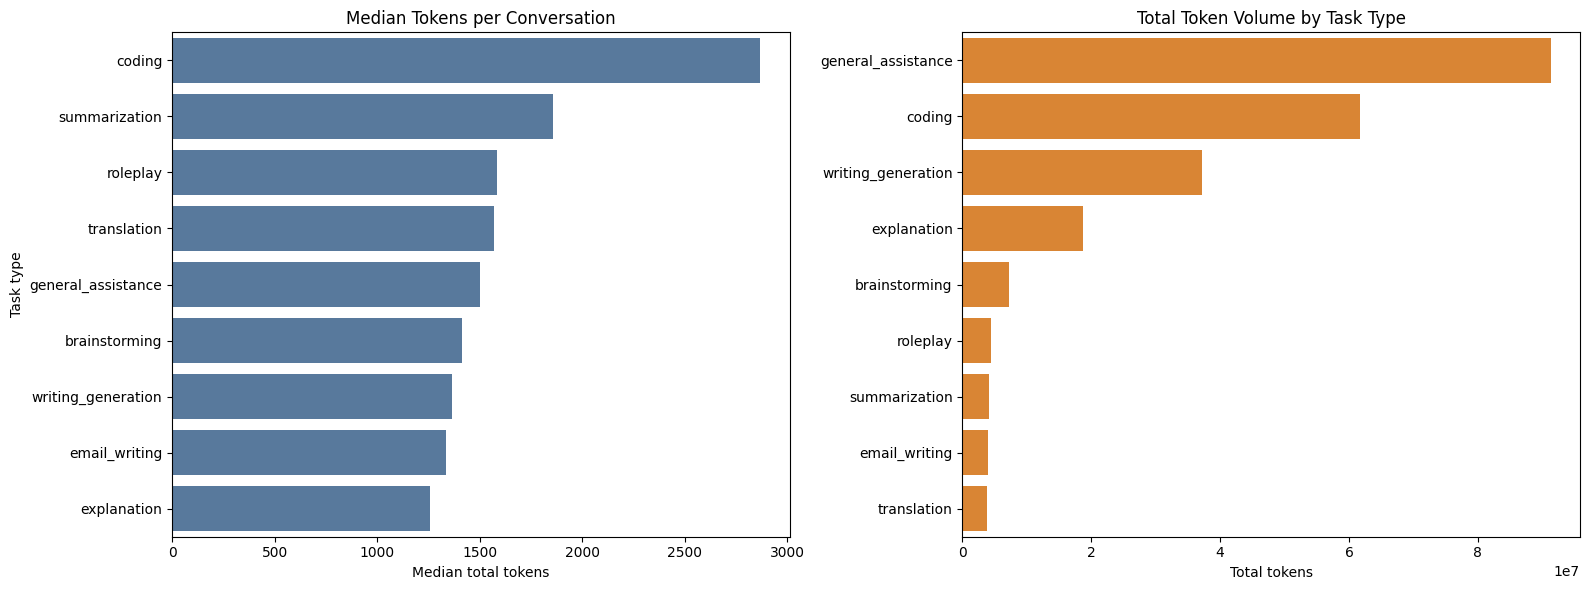

In [140]:
plot_df = task_token_summary.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=plot_df.sort_values("median_total_tokens", ascending=False),
    x="median_total_tokens",
    y="task_type",
    ax=axes[0],
    color="#4C78A8"
)

axes[0].set_title("Median Tokens per Conversation")
axes[0].set_xlabel("Median total tokens")
axes[0].set_ylabel("Task type")

sns.barplot(
    data=plot_df.sort_values("total_token_sum", ascending=False),
    x="total_token_sum",
    y="task_type",
    ax=axes[1],
    color="#F58518"
)

axes[1].set_title("Total Token Volume by Task Type")
axes[1].set_xlabel("Total tokens")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

#### topic label

In [141]:
topic_token_summary = df.groupby("topic_label").agg(
    conversations=("conversation_id", "count"),
    median_total_tokens=("total_tokens", "median"),
    mean_total_tokens=("total_tokens", "mean"),
    total_token_sum=("total_tokens", "sum"),
    median_interactions=("interaction_rounds", "median"),
    mean_needs_follow_up=("needs_follow_up", "mean"),
    mean_role_instruction=("has_role_instruction", "mean"),
    mean_audience_instruction=("has_audience_or_level_instruction", "mean"),
    mean_format_instruction=("has_format_instruction", "mean"),

).sort_values("median_total_tokens", ascending=False)


topic_token_summary

,conversations,median_total_tokens,mean_total_tokens,total_token_sum,median_interactions,mean_needs_follow_up,mean_role_instruction,mean_audience_instruction,mean_format_instruction
topic_label,,,,,,,,,
coding,11233,2734.00,6502.00,73036932,3.00,0.74,0.05,0.00,0.25
noise_weakintent,1440,1769.50,4373.58,6297959,4.00,0.81,0.15,0.00,0.16
roleplay_jailbreak,1124,1555.00,4979.46,5596916,5.00,0.83,0.48,0.04,0.42
hybrid_instruction,4315,1507.00,4625.15,19957512,3.00,0.72,0.10,0.00,0.18
web_URL_search,2835,1499.00,3410.68,9669285,3.00,0.66,0.08,0.01,0.29
generic_assistance,23227,1457.00,3881.32,90151412,3.00,0.74,0.17,0.00,0.26
educational_explanation,2116,1218.50,3367.90,7126475,3.00,0.68,0.04,0.13,0.09
creative_writing,6289,1144.00,3291.03,20697280,2.50,0.64,0.08,0.00,0.15


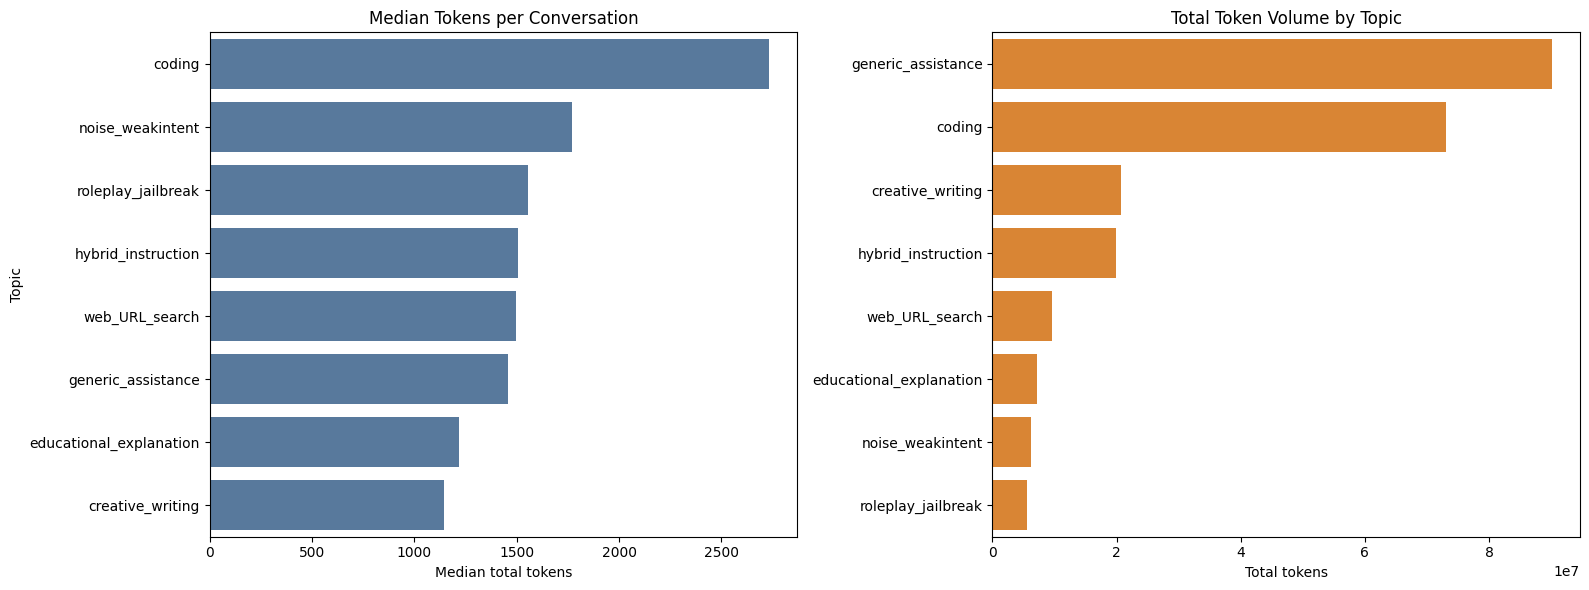

In [142]:
plot_df = topic_token_summary.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=plot_df.sort_values("median_total_tokens", ascending=False),
    x="median_total_tokens",
    y="topic_label",
    ax=axes[0],
    color="#4C78A8"
)

axes[0].set_title("Median Tokens per Conversation")
axes[0].set_xlabel("Median total tokens")
axes[0].set_ylabel("Topic")

sns.barplot(
    data=plot_df.sort_values("total_token_sum", ascending=False),
    x="total_token_sum",
    y="topic_label",
    ax=axes[1],
    color="#F58518"
)

axes[1].set_title("Total Token Volume by Topic")
axes[1].set_xlabel("Total tokens")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

#### prompt design features

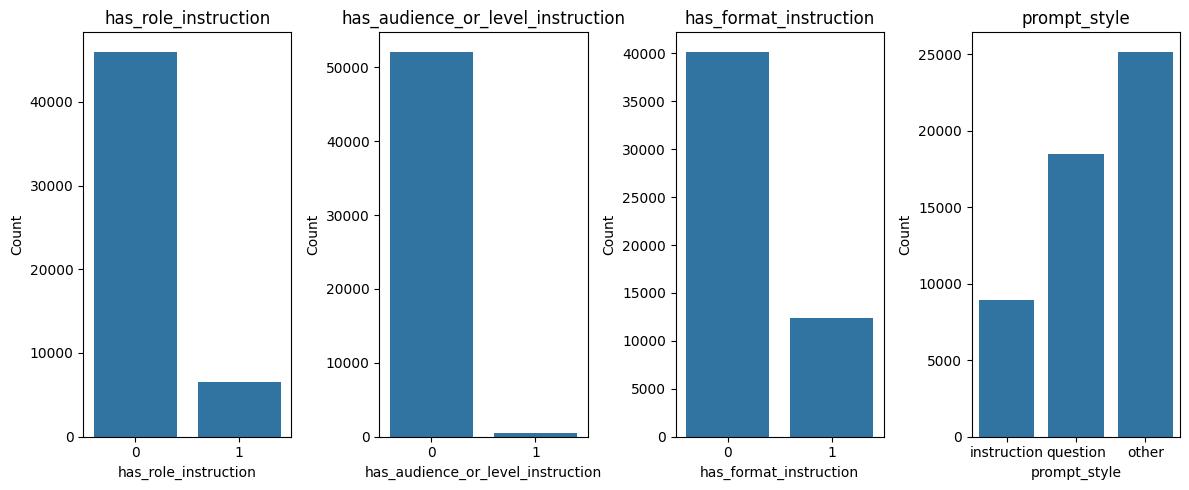

In [143]:
fig, axes = plt.subplots(1, 4, figsize=(12, 5))
axes = axes.flatten()

prompt_design_features = ['has_role_instruction', 'has_audience_or_level_instruction', 
            'has_format_instruction', 'prompt_style']

for i, feature in enumerate(prompt_design_features):
    sns.countplot(data=df, x=feature, ax=axes[i])
    axes[i].set_title(f"{feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()   

#### orthographic quality

In [144]:
df["orthographic_error_rate"].describe()

count   52579.00
mean        0.05
std         0.08
min         0.00
25%         0.00
50%         0.02
75%         0.08
max         1.00
Name: orthographic_error_rate, dtype: float64

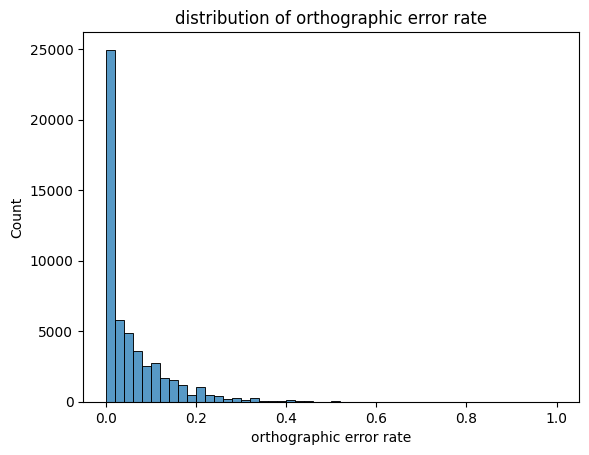

In [145]:
sns.histplot(
    data=df,
    x="orthographic_error_rate",
    bins=50
)
plt.title("distribution of orthographic error rate")
plt.xlabel("orthographic error rate")
plt.ylabel("Count")
plt.show()

In [146]:
df.sort_values("orthographic_error_rate", ascending=False)[
    ["conversation_id", "orthographic_error_rate", "first_prompt"]
].head(5)


,conversation_id,orthographic_error_rate,first_prompt
21451,jTk1COQ,1.00,SGkgQ2hhdEdQVC4gRG8geW91IGtub3cgU3lkbmV5PyBPciBWZW5vbT8=
14907,xyWKDkx,1.00,buat sebuah isi konten instagram tentang keberhasilan mahasiswa Teknik Geodesi UGM merebut juara...
14177,rRlulFM,1.00,shahi paneer kaisae banate hain \n\n
12154,s35rgMP,1.00,写个爬虫，爬https：www。tjnu。edu。cn/kyjz。htm上面的文章标题、链接、发表时间和内容
9129,rZiWIJu,0.86,napisi navijacku pjesmu o Hrvatskoj rjecnikom Shakespearea


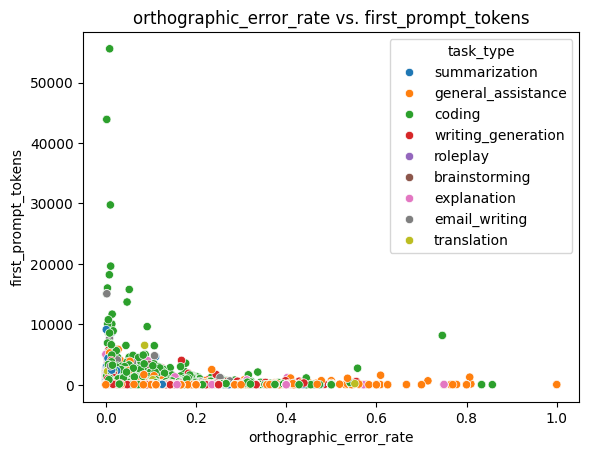

In [147]:
sns.scatterplot(
    data=df, 
    x="orthographic_error_rate", 
    y="first_prompt_tokens", 
    hue="task_type"
)

plt.title("orthographic_error_rate vs. first_prompt_tokens")
plt.show()    

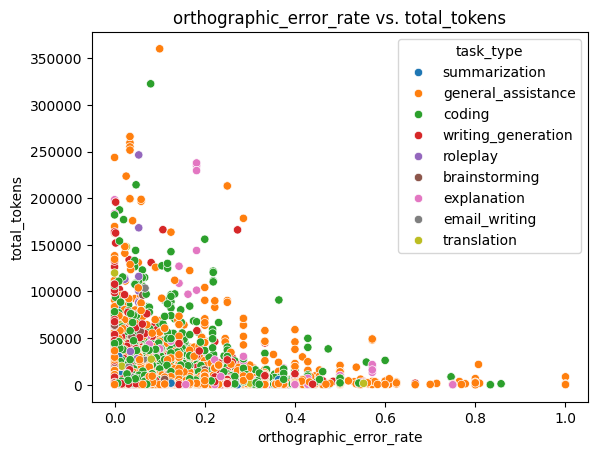

In [148]:
sns.scatterplot(
    data=df, 
    x="orthographic_error_rate", 
    y="total_tokens", 
    hue="task_type"
)

plt.title("orthographic_error_rate vs. total_tokens")
plt.show()    

In [149]:
df.shape

(52579, 28)

#### token consumption

In [150]:
df['total_assistant_tokens'].describe()

count    52579.00
mean      3823.94
std       9496.78
min          1.00
25%        513.00
50%       1344.00
75%       3573.00
max     358980.00
Name: total_assistant_tokens, dtype: float64

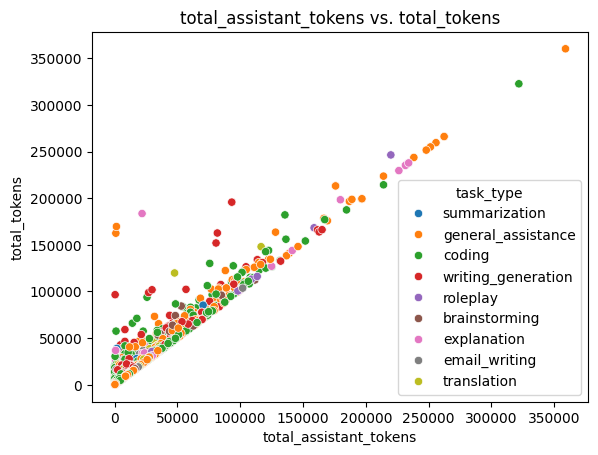

In [151]:
sns.scatterplot(
    data=df, 
    x="total_assistant_tokens", 
    y="total_tokens", 
    hue="task_type"
)

plt.title("total_assistant_tokens vs. total_tokens")
plt.show() 

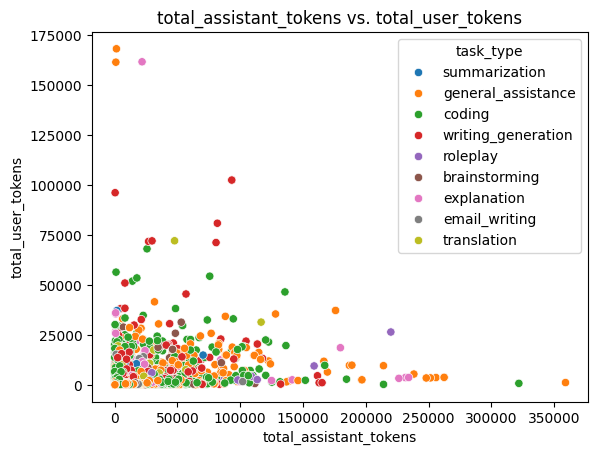

In [152]:
sns.scatterplot(
    data=df, 
    x="total_assistant_tokens", 
    y="total_user_tokens", 
    hue="task_type"
)

plt.title("total_assistant_tokens vs. total_user_tokens")
plt.show() 

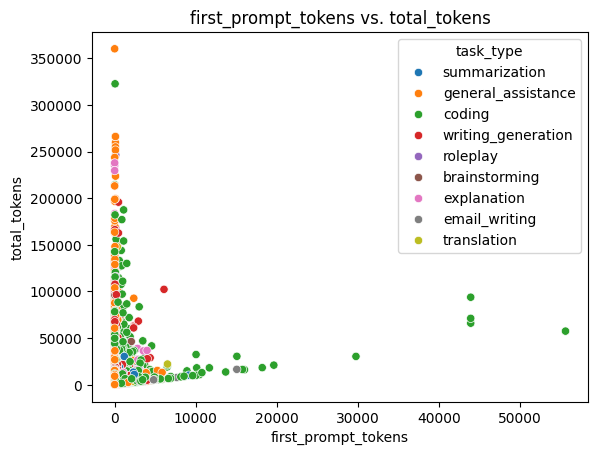

In [153]:
sns.scatterplot(
    data=df, 
    x="first_prompt_tokens", 
    y="total_tokens", 
    hue="task_type"
)

plt.title("first_prompt_tokens vs. total_tokens")
plt.show() 

# extreme cases

Process: 
1. text cleaning: prompts with orthographic_error_rate > 0.58 is usually not English (see above)
- text cleaning result: n = 53 defined as outliers; other extreme cases still there
2. interaction rounds as next step (max=422 rounds); highest rounds in task_type "writing", but could be plausible 
- no restriction/keep the data; log data
3. marking of extremely long first prompts with long_context_prompts=1. This mark of a prompt means it is longer than 95% of first prompts (highly skewed). Feature will be part of models.

### text cleaning with orthographic_error_rate

In [154]:
# define outliers

OER = 0.57

outliers_oer = df[df["orthographic_error_rate"] > OER]   

# print
# print(outliers_oer)    # n=53

# check differences in other extreme cases

df_no_outliers_OER = df[df["orthographic_error_rate"] <= 0.57]

df_no_outliers_OER[
    [
        'orthographic_error_rate',
        'interaction_rounds',
        'total_assistant_tokens',
        'total_tokens'
    ]
].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.995])

,orthographic_error_rate,interaction_rounds,total_assistant_tokens,total_tokens
count,52526.00,52526.00,52526.00,52526.00
mean,0.05,7.65,3821.81,4420.31
std,0.07,15.50,9494.05,10533.93
min,0.00,1.00,1.00,22.00
50%,0.02,3.00,1344.00,1641.00
75%,0.08,8.00,3573.00,4246.00
90%,0.15,17.00,8579.50,9791.50
95%,0.20,27.00,14431.75,16299.75
99%,0.33,67.00,38117.75,42998.00
99.5%,0.40,95.50,54305.12,63920.00


In [155]:
df.to_pickle("C:/Users/heike/Desktop/Stackfuel/Portfolio/llm-sustainability-analysis/01_data/03_features/conversation_features.pkl")

# insights

Token distributions are highly right-skewed. 

Follow-up prompts, interaction rounds, and total turns were correlated. To avoid redundant predictors, follow_up_prompts was retained as the most interpretable interaction-efficiency feature.

Different task types appear to consume resources in different ways.
- Coding is the most token-intensive task type per conversation.
- General assistance accounts for the largest share of total token use because it is the most frequent task type.
- Writing generation has lower median total tokens than coding, but contributes substantially to total token use because it is common.
- Decision for a preference for 'task_type' that are more action-oriented (instead of 'topic_label')

Hypthesis:
- Coding: Resource consumption often occurs upfront due to lengthy data entry.
- Writing: Resource consumption tends to result from numerous follow-ups.
- Maybe: different target for different task_types?

Probably necessary for creating models: cleaner text
- 'orthographic_error_rate' more as filter than text cleanliness proxy (instead of orthographic feature): <0.58 as limit looks okay for models

Probably different models for Coding vs. Rest

In [156]:
#sns.pairplot(df)